In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Uno Game

Before 2018 there were 108 Cards as follows: [ref](https://service.mattel.com/instruction_sheets/HJH90-Eng.pdf)
- 19 Blue cards - 0 to 9, 0-9 and 1-9.
- 19 Green cards - 0 to 9, 0-9 and 1-9.
- 19 Red cards - 0 to 9, 0-9 and 1-9.
- 19 Yellow cards - 0 to 9, 0-9 and 1-9.
- 8 Draw Two cards - 2 each in blue, green, red and yellow
- 8 Reverse cards - 2 each in blue, green, red and yellow
- 8 Skip cards - 2 each in blue, green, red and yellow
- 4 Wild cards
- 4 Wild Draw Four cards
We use these as this ignores the optional rule cards added in the 2022 set.

Using the 2022 rule set: [ref](https://service.mattel.com/instruction_sheets/HJH90-Eng.pdf)



In [2]:
STACKING_ALLOWED = True
# 0-9 represented as 0, ..., 9 : numbers
# skip represented as 10
# reverse represented as 11
# +2 represented as 12
# color (not used, only as placeholder for wild) as 13
# color+4 (not used, only as placeholder for wild) as 14
# blue == 0,  green == 1, red == 2, yellow == 3, wild == 4
def parse(card):
    colors = ["B", "G", "R", "Y", "W"]
    val = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "S", "R", "+", "C", "="]
    return colors[card//15] + val[card%15]

single = np.concatenate([np.arange(13), np.arange(start=1, stop=13)])

unshuffled_deck = np.concatenate([
    single,     #blue
    single+15,  #green
    single+30,  #red
    single+45,  #yellow
    [73,73,73,73, 74,74,74,74] # Wilds (73) and Wild+4 (74)
]) 

shuffled = unshuffled_deck.copy()
np.random.shuffle(shuffled)

print([f"{i}:{parse(i)}" for i in unshuffled_deck])

['0:B0', '1:B1', '2:B2', '3:B3', '4:B4', '5:B5', '6:B6', '7:B7', '8:B8', '9:B9', '10:BS', '11:BR', '12:B+', '1:B1', '2:B2', '3:B3', '4:B4', '5:B5', '6:B6', '7:B7', '8:B8', '9:B9', '10:BS', '11:BR', '12:B+', '15:G0', '16:G1', '17:G2', '18:G3', '19:G4', '20:G5', '21:G6', '22:G7', '23:G8', '24:G9', '25:GS', '26:GR', '27:G+', '16:G1', '17:G2', '18:G3', '19:G4', '20:G5', '21:G6', '22:G7', '23:G8', '24:G9', '25:GS', '26:GR', '27:G+', '30:R0', '31:R1', '32:R2', '33:R3', '34:R4', '35:R5', '36:R6', '37:R7', '38:R8', '39:R9', '40:RS', '41:RR', '42:R+', '31:R1', '32:R2', '33:R3', '34:R4', '35:R5', '36:R6', '37:R7', '38:R8', '39:R9', '40:RS', '41:RR', '42:R+', '45:Y0', '46:Y1', '47:Y2', '48:Y3', '49:Y4', '50:Y5', '51:Y6', '52:Y7', '53:Y8', '54:Y9', '55:YS', '56:YR', '57:Y+', '46:Y1', '47:Y2', '48:Y3', '49:Y4', '50:Y5', '51:Y6', '52:Y7', '53:Y8', '54:Y9', '55:YS', '56:YR', '57:Y+', '73:WC', '73:WC', '73:WC', '73:WC', '74:W=', '74:W=', '74:W=', '74:W=']


In [3]:

class UnoGame:
    def __init__(self):
        self.deck = unshuffled_deck.copy()
        np.random.shuffle(self.deck)
        self.pile = np.array([])
        self.played = np.array([])
        self.draw = 0 
        self.players = [] 
        self.players_cards = []
        self.current_player = 0
        self.order = -1 
    def add_player(self, player):
        self.players.append(player)
        self.players_cards.append(np.array([], dtype=int))
    def simulate(self, random_start = True):
        assert len(self.players) > 0

        # setup
        if random_start:
            self.current_player = np.random.randint(0, len(self.players))
            
        for i in range(len(self.players)):
            self.players[i].simulate_start()
            self.players_cards[i] = self.deck[0:7]
            self.deck = self.deck[7:]

        self.pile = np.array([self.deck[0]])
        self.deck = self.deck[1:]

        while True:
            playable = valid_cards(self.players_cards[self.current_player], self.pile, self.draw)
            if len(playable) == 0:
                played = -1
            else:
                player_counts = [len(i) for i in self.players_cards]
                player_counts = player_counts[self.current_player::self.order] + player_counts[:self.current_player:self.order]
                played = self.players[self.current_player].choice(playable, self.players_cards[self.current_player], self.pile, self.played, self.draw, player_counts)

            if played == -1: # Picked up a card
                self.draw = self.draw if self.draw else 1 # Set to min of 1
                end_game = False
                while self.draw > 0:
                    self.players_cards[self.current_player] = np.append(self.players_cards[self.current_player], self.deck[0])
                    self.deck = self.deck[1:]
                    self.draw = self.draw - 1
                    if self.shuffle_pile_if_empty_deck():
                        end_game = True
                        break
                if end_game: break
                self.draw = 0
                self.players_cards[self.current_player] = self.players_cards[self.current_player]
            else:
                assert valid_card(played, self.pile, self.draw)
                # print(f"{self.current_player}: play {parse(played)} on {parse(self.pile[-1])}")

                # Remove card from player's hand'
                mask = np.ones(len(self.players_cards[self.current_player]), dtype=bool)
                mask[np.argmax(self.players_cards[self.current_player]==played)] = False
                self.players_cards[self.current_player] = self.players_cards[self.current_player][mask]

                # Special cards
                if played % 15 == 10: # Skip
                    self.current_player = (self.current_player + self.order) % len(self.players)
                elif played % 15 == 11: # Reverse
                    self.order = -self.order
                    if len(self.players) == 2: # Skip if only two players
                        self.current_player = (self.current_player + self.order) % len(self.players)
                elif played % 15 == 12: # Draw 2
                    self.draw = self.draw + 2
                elif played // 15 == 4: # Wild
                    if played == 74: # Wild draw 4
                        self.draw = self.draw + 4
                    played = self.players[self.current_player].choice_color(playable, self.players_cards[self.current_player],self.pile, self.played, self.draw, player_counts) * 15 + played % 15

                # Add to played cards
                self.played = np.append(self.played, played)
                self.pile = np.append(self.pile, played)

            if len(self.players_cards[self.current_player]) == 0: # Won
                break

            # Next player
            self.current_player = (self.current_player + self.order) % len(self.players)
        return self.current_player
        
    def shuffle_pile_if_empty_deck(self):
        if len(self.deck) == 0:
            if len(self.pile)<=1: # Winner is he with the fewest cards
                self.current_player = np.argmin(np.array([len(i) for i in self.players_cards]))
                return True
            self.deck = self.pile[:-1].copy()
            self.deck = self.deck * (self.deck % 15 != 13) + 73 * (self.deck % 15 == 13)
            self.deck = self.deck * (self.deck % 15 != 14) + 74 * (self.deck % 15 == 14)
            self.pile = self.pile[-1:].copy()
            np.random.shuffle(self.deck)
        return False

def valid_card(card, pile, draw):
    last_card = pile[-1]

    # No stacking allowed
    draw_card = (card % 15 == 12) or (card % 15 == 14)
    if draw>0:
        if STACKING_ALLOWED:
            return draw_card
        else:
            return False

    color = card // 15
    value = card % 15
    # Equal value,  equal color,  wild card
    return (value == last_card%15) or (color == last_card//15) or (color == 4)

def valid_cards(cards, pile, draw): # Vectorised
    last_card = pile[-1]
    nparray = np.array(cards)

    if draw>0:
        if STACKING_ALLOWED:
            card_filter = (nparray % 15 == 12) | (nparray % 15 == 14)
        else:
            return np.array([])
    else:  # Equal value,  equal color,  wild card
        card_filter = (
            (nparray%15 == last_card%15) | 
            (nparray//15 == last_card//15)  | 
            (nparray//15 == 4)
        )

    return nparray[card_filter]


class Player:
    def __init__(self, strategy):
        self.strategy_func = None
        self.strategy = strategy
        self.pick_color = 0
    def __repr__(self):
        return f"Player({self.strategy})"
    def __str__(self):
        return self.strategy
    def simulate_start(self): # Useful for resetting variables
        pass
    def set_strategy(self, func):
        self.strategy_func = func
    def choice(self, playable_cards, player_cards, pile, played, draw, players):
        return self.strategy_func(self, playable_cards, player_cards, pile, played, draw, players)
    def choice_color(self, playable_cards, player_cards,  pile, played, draw, players):
        return self.pick_color

In [4]:
# Test valid_card
print(f"Card: {shuffled[0]} - {parse(shuffled[0])}")
text = ""
for i in unshuffled_deck:
    if valid_card(i, [shuffled[0]], 0):
        text += f"{parse(i)}, "
print(text)

Card: 7 - B7
B0, B1, B2, B3, B4, B5, B6, B7, B8, B9, BS, BR, B+, B1, B2, B3, B4, B5, B6, B7, B8, B9, BS, BR, B+, G7, G7, R7, R7, Y7, Y7, WC, WC, WC, WC, W=, W=, W=, W=, 


In [5]:
# Test valid_cards
print(f"Card: {shuffled[0]} - {parse(shuffled[0])}")
text = ', '.join([parse(i) for i in valid_cards(unshuffled_deck, [shuffled[0]], 0)])
print(text)
text = ', '.join([parse(i) for i in valid_cards(unshuffled_deck[0:3], [shuffled[0]], 0)])
print(text)

Card: 7 - B7
B0, B1, B2, B3, B4, B5, B6, B7, B8, B9, BS, BR, B+, B1, B2, B3, B4, B5, B6, B7, B8, B9, BS, BR, B+, G7, G7, R7, R7, Y7, Y7, WC, WC, WC, WC, W=, W=, W=, W=
B0, B1, B2


In [6]:
strategies = []
rollout_strategies = []

def strategy(name):
    def decorator(function):
        player = Player(name)
        player.set_strategy(function)
        strategies.append(player)
        return player.choice
    return decorator

@strategy("low_value_first")
def min_choice(player, playable_cards, player_cards, pile, played, draw, players):
    playable_sorted = playable_cards[(playable_cards%15).argsort()]
    player.pick_color = np.argmax(np.bincount(player_cards//15))
    return playable_sorted[0]

@strategy("high_value_first")
def max_choice(player, playable_cards, player_cards, pile, played, draw, players):
    playable_sorted = playable_cards[(playable_cards%15).argsort()]
    player.pick_color = np.argmax(np.bincount(player_cards//15))
    return playable_sorted[-1]

@strategy("color_streak")
def streak_choice(player, playable, hand, pile, played, draw, players):
    """
    1. Pick a color the opponent is drawing
    2. Keep playing cards of that color until none left
    3. Last card should match a number you have in another color
    """
    last_pile = pile[-1]
    last_color = last_pile // 15
    last_value = last_pile % 15

    hand_len = len(hand)  
    
    same_color = playable[playable // 15 == last_color]


    if len(same_color) > 0:
        card_to_play = same_color[0]  
    else:
        card_to_play = playable[0]    

    
    if hand_len == 2: 
        
        last_card = None
        for c in playable:
           
            val = c % 15
            colors_in_hand = set((hand // 15)[hand % 15 == val])
            if val not in [13,14] and len(colors_in_hand - {c//15}) > 0:
                last_card = c
                break
        if last_card is not None:
            card_to_play = last_card


    colors_in_hand = hand[hand // 15 != 4] // 15
    player.pick_color = np.argmax(np.bincount(colors_in_hand)) if len(colors_in_hand) else 0 if len(colors_in_hand) > 0 else 0

    return card_to_play
    
@strategy("planned_finish")
def planned_finish_choice(player, playable, hand, pile, played, draw, players):
    """
    1. Start with your dominant color
    2. Keep track of cards, save wildcard for last
    3. End with a card that matches a number of another card in your hand
    4. Play the last card in the color you need
    """
    hand_len = len(hand)
    
    # Exclude wilds for first plays
    non_wild_playable = playable[playable // 15 != 4]
    
    # Determine dominant color
    colors_in_hand = hand[hand // 15 != 4] // 15
    dominant_color = np.argmax(np.bincount(colors_in_hand)) if len(colors_in_hand) > 0 else 0
    
    # Step 1: Play dominant color if available
    same_color = non_wild_playable[non_wild_playable // 15 == dominant_color]
    if len(same_color) > 0:
        card_to_play = same_color[0]
    else:
        card_to_play = non_wild_playable[0] if len(non_wild_playable) > 0 else playable[0]
    
    # Step 2: Optimize last card
    if hand_len == 2:  
        last_card = None
        for c in playable:
            val = c % 15
            colors_with_same_val = set((hand // 15)[hand % 15 == val])
            if len(colors_with_same_val) > 0 and c // 15 != 4:
                last_card = c
                break
        if last_card is not None:
            card_to_play = last_card
    
    # Step 3: Set pick_color for wilds if needed
    colors_in_hand = hand[hand // 15 != 4] // 15
    player.pick_color = np.argmax(np.bincount(colors_in_hand)) if len(colors_in_hand) else 0 if len(colors_in_hand) > 0 else 0
    
    return card_to_play 

@strategy("random_play")
def random_choice(player, playable, hand, pile, played, draw, players):
    """
    Random strategy:
    - Plays any valid card from playable
    - If wild, chooses color randomly from cards in hand
    """
    # Pick a random valid card
    card_to_play = np.random.choice(playable)
    
    # If the card is a wild, pick a color randomly
    if card_to_play // 15 == 4:  # wild or wild+4
        colors_in_hand = hand[hand // 15 != 4] // 15  # exclude wilds
        if len(colors_in_hand) > 0:
            player.pick_color = np.random.choice(colors_in_hand)
        else:
            player.pick_color = np.random.randint(0, 4)
    
    return card_to_play    

@strategy("dynamic_best")
def dynamic_best_choice(player, playable, hand, pile, played, draw, players):
    """
    Strategy: Chooses the best card based on:
    - Dominant color in hand
    - Card value duplicates
    - Special cards to affect opponents
    - Plans last card to match a number in hand
    """
    last_card = pile[-1]
    last_color = last_card // 15
    last_value = last_card % 15

    hand_colors = hand[hand // 15 != 4] // 15  # Exclude wilds
    dominant_color = np.argmax(np.bincount(hand_colors)) if len(hand_colors) > 0 else 0

    # Score each playable card
    scores = []
    for c in playable:
        score = 1  # Base score
        color = c // 15
        value = c % 15

        # Bonus for dominant color
        if color == dominant_color:
            score += 2

        # Bonus if value exists elsewhere in hand
        if value < 10 and np.sum(hand % 15 == value) > 1:
            score += 1

        # Offensive play if opponent has 1-2 cards
        if value in [10,11,12,14]:  # Skip, Reverse, Draw2, WildDraw4
            for opp_cards in players:
                if opp_cards <= 2:
                    score += 3

        # Wild cards get bonus for color control
        if color == 4:
            score += 2

        scores.append(score)

    # Pick the card with max score
    max_idx = np.argmax(scores)
    card_to_play = playable[max_idx]

    # Set color for wild cards
    if card_to_play // 15 == 4:
        # Pick the color you have most
        colors_in_hand = hand[hand // 15 != 4] // 15
        player.pick_color = np.argmax(np.bincount(colors_in_hand)) if len(colors_in_hand) else 0 if len(colors_in_hand) > 0 else 0
    else:
        player.pick_color = card_to_play // 15

    # Last card planning: if only 2 cards left, try to leave last card matching a number in hand
    if len(hand) == 2:
        # Look for a card that matches a number you have in another color
        for c in playable:
            if c // 15 != 4:  # Not a wild card
                val = c % 15
                # Check if you have another card with same value
                matching_cards = hand[(hand % 15 == val) & (hand // 15 != 4)]
                if len(matching_cards) > 0:
                    return c  
    return card_to_play

@strategy("card_counting")
def card_counting_choice(player, playable, hand, pile, played, draw, players):
    """
    Memory-based strategy:
    - Track colors already played
    - Choose colors opponents likely do NOT have
    """
    
    # Count colors played so far
    played_colors = (played.astype(int)[played.astype(int) // 15 != 4]) // 15
    
    if len(played_colors) > 0:
        color_counts = np.bincount(played_colors, minlength=4)
        rare_color = np.argmin(color_counts)
    else:
        rare_color = None

    best_card = playable[0]
    
    for c in playable:
        if rare_color is not None and c // 15 == rare_color:
            best_card = c
            break

    card_to_play = best_card

    # Wild color choice
    if card_to_play // 15 == 4:
        if rare_color is not None:
            player.pick_color = rare_color
        else:
            colors_in_hand = hand[hand // 15 != 4] // 15
            player.pick_color = np.argmax(np.bincount(colors_in_hand)) if len(colors_in_hand) else 0 if len(colors_in_hand) > 0 else 0
    else:
        player.pick_color = card_to_play // 15

    return card_to_play

@strategy("opponent_block")
def opponent_block_choice(player, playable, hand, pile, played, draw, players):
    """
    Defensive strategy:
    - If opponent close to winning, use attack cards
    """

    # Check if any opponent close to winning
    danger = any(p <= 2 for p in players if p != len(hand))

    if danger:
        for c in playable:
            if c % 15 in [10,11,12,14]:  # skip reverse draw2 wild+4
                card_to_play = c
                break
        else:
            card_to_play = playable[0]
    else:
        card_to_play = playable[0]

    # Set wild color
    if card_to_play // 15 == 4:
        colors_in_hand = hand[hand // 15 != 4] // 15
        player.pick_color = np.argmax(np.bincount(colors_in_hand)) if len(colors_in_hand) else 0 if len(colors_in_hand) > 0 else 0
    else:
        player.pick_color = card_to_play // 15

    return card_to_play

@strategy("risk_aware")
def risk_aware_choice(player, playable, hand, pile, played, draw, players):
    """
    Risk-aware strategy:
    - Avoid numbers frequently played
    - Prefer uncommon values
    """

    values_played = played.astype(int) % 15
    
    if len(values_played) > 0:
        value_counts = np.bincount(values_played, minlength=15)
    else:
        value_counts = np.zeros(15)

    scores = []

    for c in playable:
        value = c % 15
        
        score = -value_counts[value]
        
        color = c // 15
        hand_colors = hand[hand // 15 != 4] // 15
        if len(hand_colors) > 0 and color == np.argmax(np.bincount(hand_colors)):
            score += 2

        scores.append(score)

    card_to_play = playable[np.argmax(scores)]

    # Wild color
    if card_to_play // 15 == 4:
        colors_in_hand = hand[hand // 15 != 4] // 15
        player.pick_color = np.argmax(np.bincount(colors_in_hand)) if len(colors_in_hand) else 0 if len(colors_in_hand) > 0 else 0
    else:
        player.pick_color = card_to_play // 15

    return card_to_play
 

In [7]:
wins = [0, 0]
trials = 1000

for i in range(1, trials + 1):
    game = UnoGame()
    
    game.add_player(strategies[-1])  
    game.add_player(strategies[7])   
    
    winner = game.simulate()  
    wins[winner] += 1
    
    del game

# Show results and winning probabilities
total_games = sum(wins)
print(f"After {trials} games with random starting player:")

for idx, player in enumerate([strategies[-1], strategies[7]]):
    prob = wins[idx] / total_games
    print(f"{player} won {wins[idx]} games → probability {prob:.2%}")

After 1000 games with random starting player:
risk_aware won 482 games → probability 48.20%
opponent_block won 518 games → probability 51.80%



Strategy Win Probability Matrix

First Player Strategy  low_value_first high_value_first color_streak  \
Second Player Strategy                                                 
low_value_first                  52.1%            48.4%        51.3%   
high_value_first                 51.6%            51.4%        53.5%   
color_streak                     48.7%            46.5%        49.2%   
planned_finish                   48.6%            46.8%        50.7%   
random_play                      52.4%            51.0%        56.5%   
dynamic_best                     54.6%            55.3%        59.5%   
card_counting                    60.3%            55.2%        61.8%   
opponent_block                   55.2%            48.9%        56.6%   
risk_aware                       56.9%            52.9%        58.9%   
Column Avg                       53.4%            50.7%        55.3%   

First Player Strategy  planned_finish random_play dynamic_best card_counting  \
Second Player Strateg

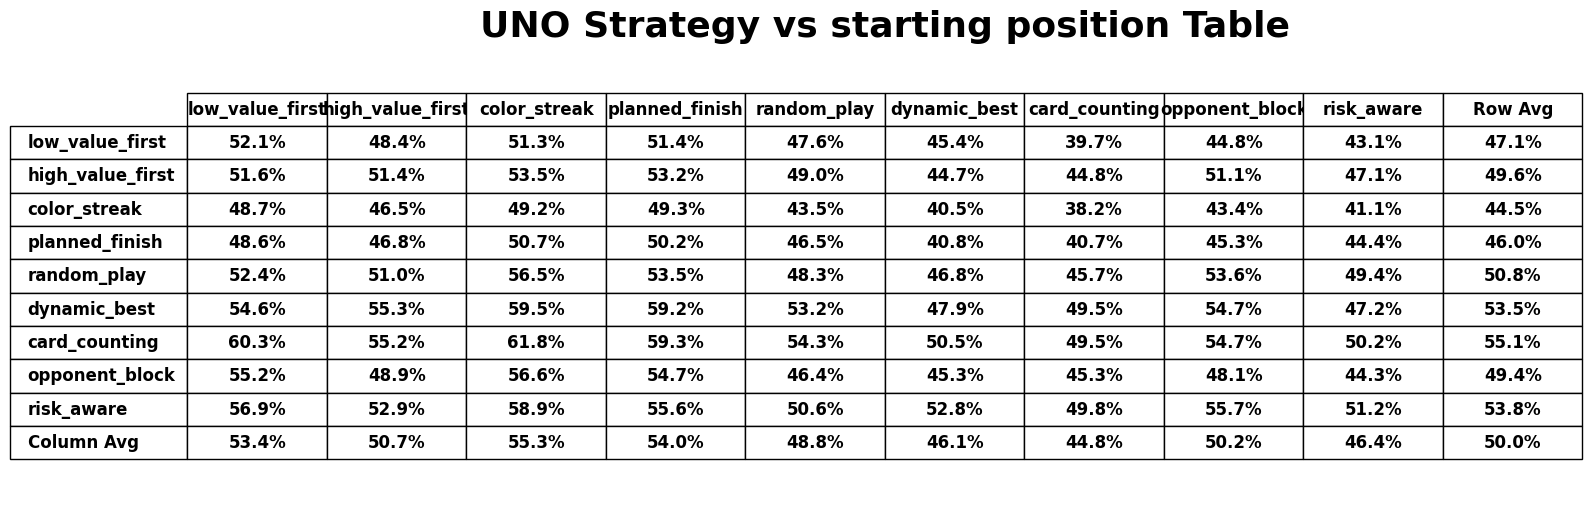

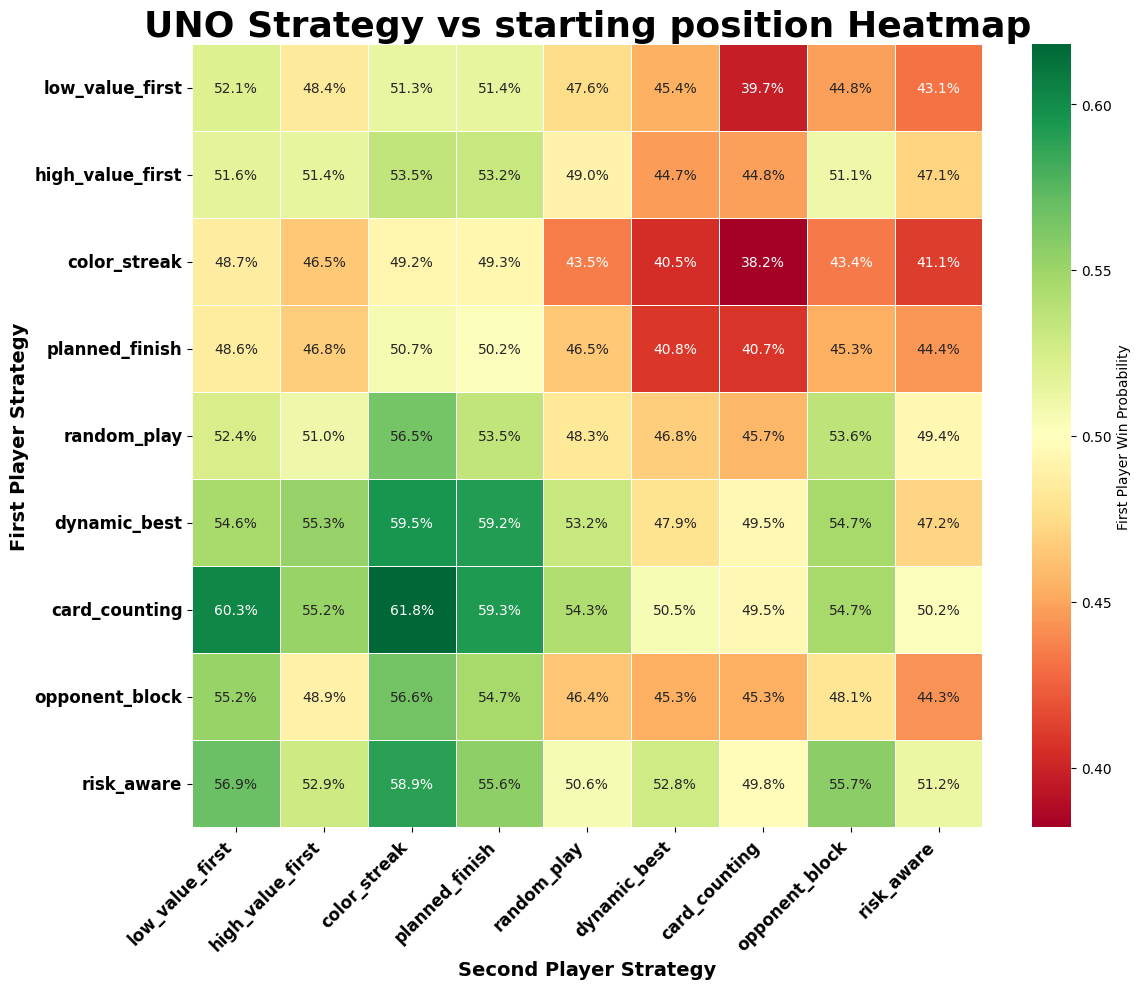

In [8]:
# Strategy vs starting position
np.random.seed(42)
random.seed(42)

trials = 1000

strategy_names = [p.strategy for p in strategies]

matrix = pd.DataFrame(np.nan, index=strategy_names, columns=strategy_names)

for i, first_player in enumerate(strategies):
    for j, second_player in enumerate(strategies):

        if pd.notna(matrix.iloc[j, i]):
            continue

        wins_first = 0

        for _ in range(trials):
            game = UnoGame()
            game.add_player(first_player)
            game.add_player(second_player)

            winner = game.simulate(random_start=False)

            if winner == 0:
                wins_first += 1

        p_first = wins_first / trials

        matrix.iloc[j, i] = p_first
        matrix.iloc[i, j] = 1 - p_first

matrix.index.name = "Second Player Strategy"
matrix.columns.name = "First Player Strategy"

matrix["Row Avg"] = matrix.mean(axis=1)
matrix.loc["Column Avg"] = matrix.mean()

matrix_display = matrix.map(lambda x: f"{x:.1%}" if pd.notna(x) else "")

print("\nStrategy Win Probability Matrix\n")
print(matrix_display)

# MATPLOTLIB TABLE

fig, ax = plt.subplots(figsize=(12,6))

ax.axis("tight")
ax.axis("off")

table = ax.table(
    cellText=matrix_display.values,
    rowLabels=matrix_display.index,
    colLabels=matrix_display.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)

for key, cell in table.get_celld().items():
    cell.get_text().set_weight("bold")

table.scale(1.5,2)

plt.title("UNO Strategy vs starting position Table", fontsize=26, weight='bold')
plt.show()

# Heatmap Visualization

plt.figure(figsize=(12, 10))

sns.heatmap(
    matrix.iloc[:-1, :-1],   
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    center=0.5,
    linewidths=0.5,
    cbar_kws={"label": "First Player Win Probability"}
)

plt.title("UNO Strategy vs starting position Heatmap", fontsize=26, weight='bold')
plt.ylabel("First Player Strategy", fontsize=14, weight='bold')
plt.xlabel("Second Player Strategy", fontsize=14, weight='bold')

plt.xticks(rotation=45, ha="right", fontsize=12, weight='bold')
plt.yticks(rotation=0, fontsize=12, weight='bold')

plt.tight_layout()
plt.show()



Strategy vs Strategy Matrix

Player B Strategy low_value_first high_value_first color_streak  \
Player A Strategy                                                 
low_value_first             50.0%            55.6%        45.4%   
high_value_first            44.4%            50.0%        44.8%   
color_streak                54.6%            55.2%        50.0%   
planned_finish              52.4%            54.8%        47.5%   
random_play                 46.7%            48.2%        43.1%   
dynamic_best                44.3%            43.9%        37.8%   
card_counting               43.4%            46.4%        38.7%   
opponent_block              49.1%            51.5%        46.6%   
risk_aware                  46.4%            47.2%        43.0%   
Column Avg                  47.9%            50.3%        44.1%   

Player B Strategy planned_finish random_play dynamic_best card_counting  \
Player A Strategy                                                         
low_value_first

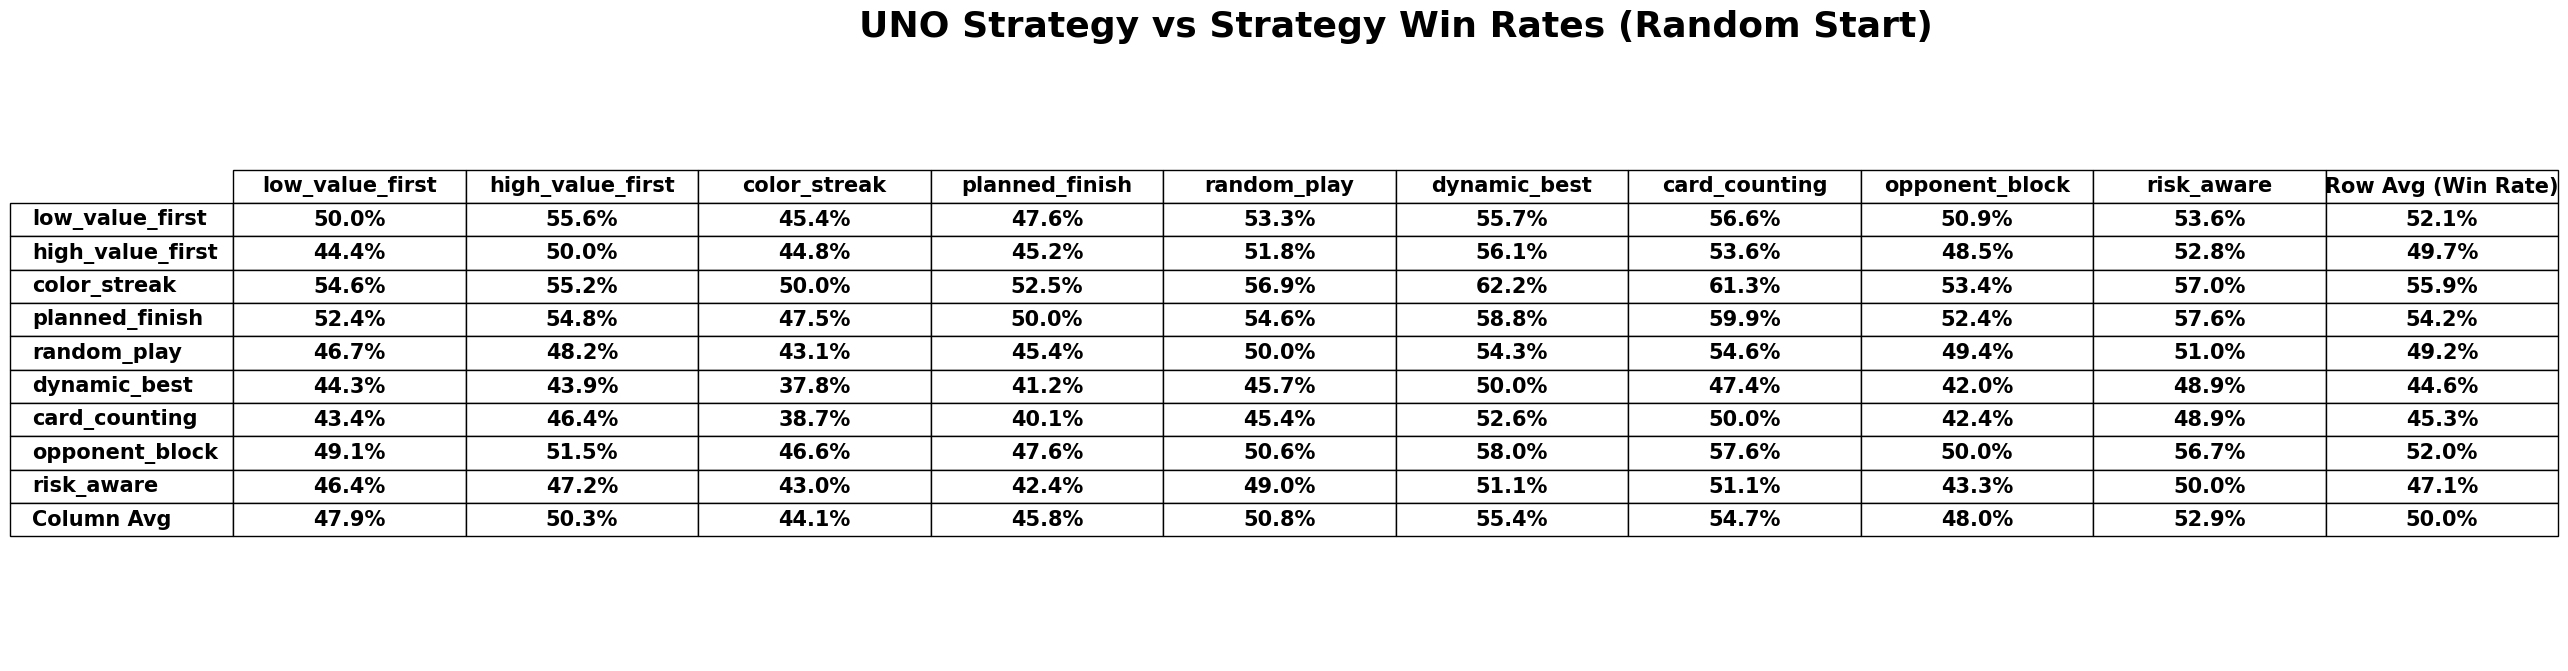

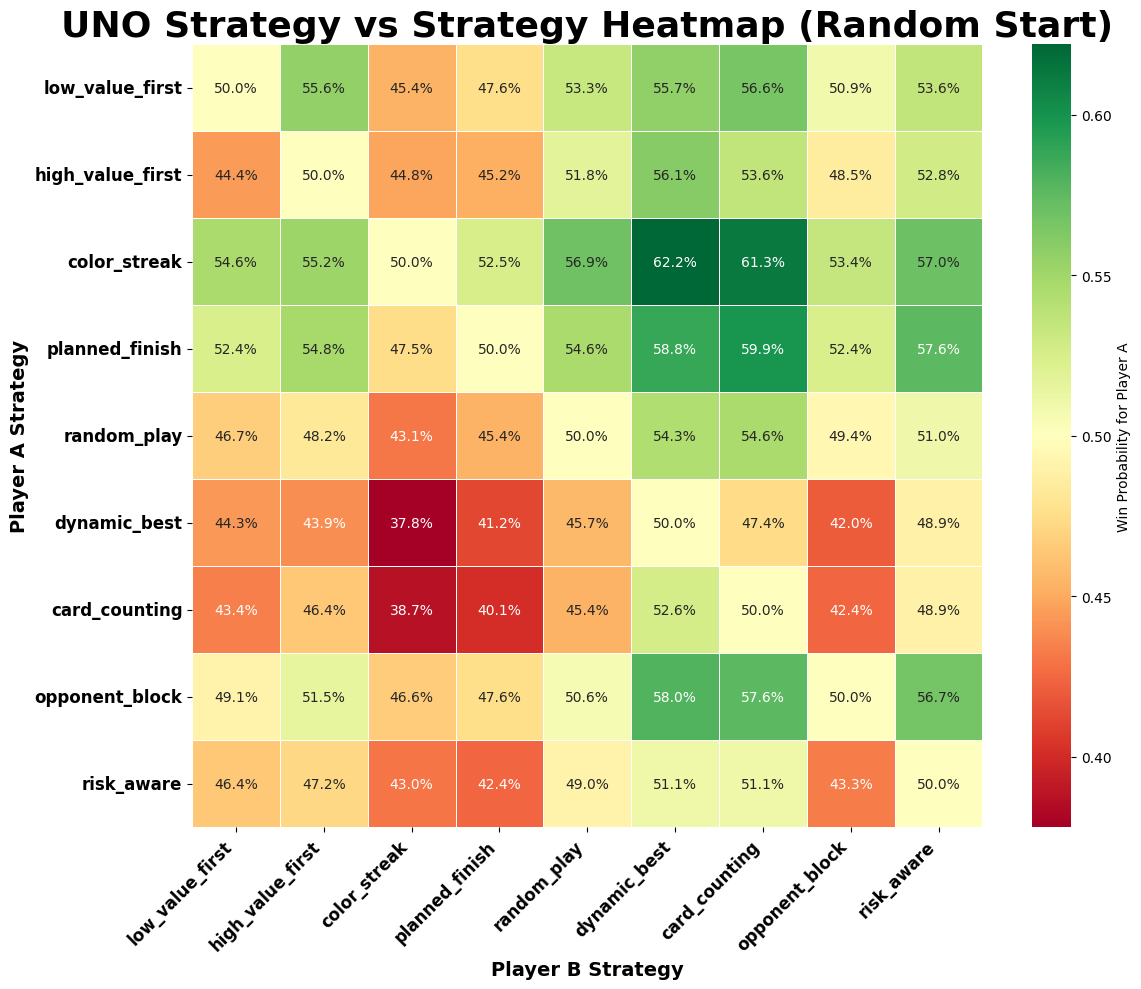

In [9]:
# Strategy vs Strategy

np.random.seed(42)
random.seed(42)

trials = 1000

strategy_names = [p.strategy for p in strategies]

matrix = pd.DataFrame(np.nan, index=strategy_names, columns=strategy_names)

for i, strat_A in enumerate(strategies):
    for j, strat_B in enumerate(strategies):

        if pd.notna(matrix.iloc[j, i]):
            continue

        wins_A = 0

        for _ in range(trials):

            game = UnoGame()

            game.add_player(strat_A)
            game.add_player(strat_B)

            # Random starting player
            winner = game.simulate(random_start=True)

            if winner == 0:
                wins_A += 1
            else:
                wins_A -= 1

        p_A = (wins_A / trials + 1) / 2

        matrix.iloc[i, j] = p_A
        matrix.iloc[j, i] = 1 - p_A

for i in range(len(strategy_names)):
    matrix.iloc[i, i] = 0.5


# Row & Column averages
matrix["Row Avg (Win Rate)"] = matrix.mean(axis=1)
matrix.loc["Column Avg"] = matrix.mean()

matrix.columns.name = "Player B Strategy"
matrix.index.name = "Player A Strategy"

pd.set_option("display.float_format", "{:.2%}".format)
matrix_display = matrix.map(lambda x: f"{x:.1%}" if pd.notna(x) else "")

print("\nStrategy vs Strategy Matrix\n")
print(matrix_display)


# MATPLOTLIB TABLE 

fig, ax = plt.subplots(figsize=(15,8))  

ax.axis("tight")
ax.axis("off")

table = ax.table(
    cellText=matrix_display.values,
    rowLabels=matrix_display.index,
    colLabels=matrix_display.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(15)

for key, cell in table.get_celld().items():
    cell.get_text().set_weight("bold")

table.scale(2.0, 2.0)  

plt.title("UNO Strategy vs Strategy Win Rates (Random Start)", fontsize=26, weight='bold')
plt.show()

# SEABORN HEATMAP
plt.figure(figsize=(12,10))

sns.heatmap(
    matrix.iloc[:-1,:-1],
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    center=0.5,
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "Win Probability for Player A"}
)

plt.title("UNO Strategy vs Strategy Heatmap (Random Start)", fontsize=26, weight='bold')

plt.xlabel("Player B Strategy", fontsize=14, weight='bold')
plt.ylabel("Player A Strategy", fontsize=14, weight='bold')

plt.xticks(rotation=45, ha="right", fontsize=12, fontweight="bold")
plt.yticks(rotation=0, fontsize=12, fontweight="bold")


plt.tight_layout()
plt.show()

Strategy vs Number of Opponents Win Rate Table
                    1v1    1v2    1v3    1v4    1v5    1v6
low_value_first  50.10% 31.80% 26.50% 20.60% 16.90% 14.30%
high_value_first 48.10% 26.40% 18.10% 12.80% 10.60%  9.00%
color_streak     50.00% 34.10% 22.00% 19.30% 16.30% 13.00%
planned_finish   51.80% 33.00% 23.20% 22.30% 20.70% 14.00%
random_play      45.20% 26.80% 17.80% 12.50% 13.30%  9.90%
dynamic_best     42.60% 26.60% 19.80% 15.40% 15.70% 11.60%
card_counting    41.00% 25.50% 19.60% 14.10% 13.40% 11.50%
opponent_block   49.70% 28.50% 20.70% 15.80% 14.50% 11.90%
risk_aware       44.90% 29.00% 22.80% 15.20% 13.50% 12.10%

Strategy vs Number of Opponents Stratified Table (Normalized Strength)
                      2P      3P      4P      5P      6P      7P
low_value_first  100.20%  95.40% 106.00% 103.00% 101.40% 100.10%
high_value_first  96.20%  79.20%  72.40%  64.00%  63.60%  63.00%
color_streak     100.00% 102.30%  88.00%  96.50%  97.80%  91.00%
planned_finish   103.60%  99.00

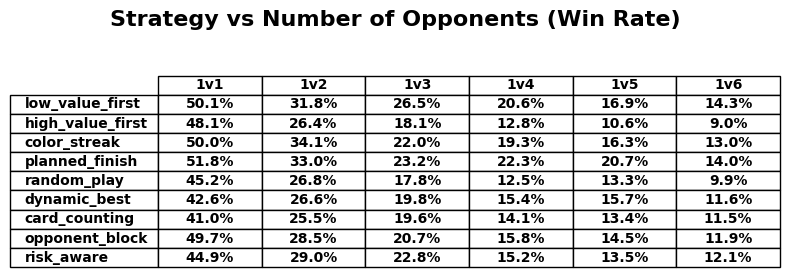

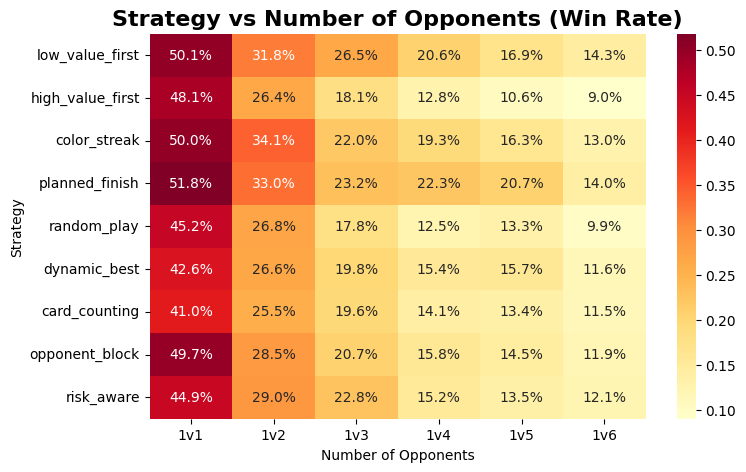

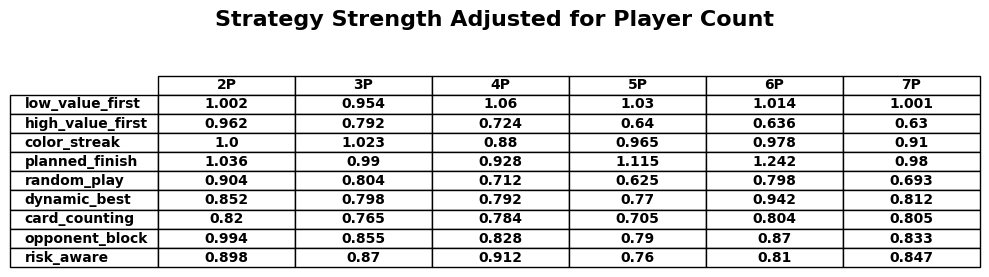

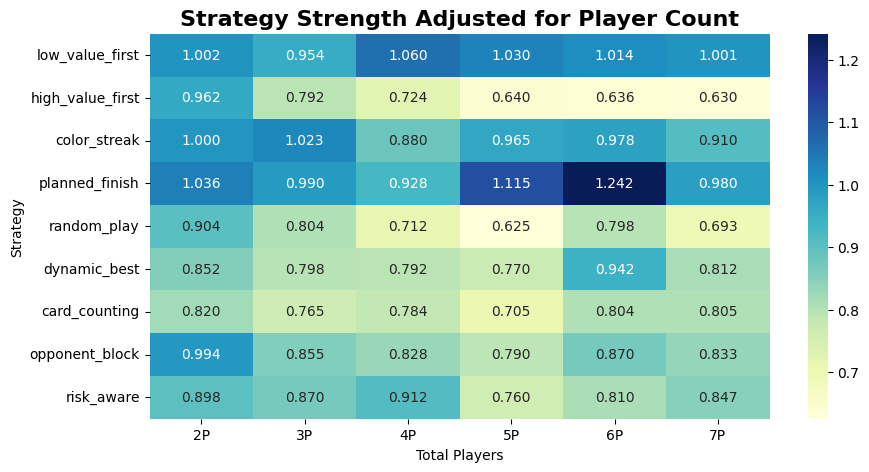

In [10]:
# Strategy vs Number of Opponents

np.random.seed(42)
random.seed(42)

trials = 1000
max_opponents = 6

strategy_names = [p.strategy for p in strategies]

results = pd.DataFrame(
    np.nan,
    index=strategy_names,
    columns=[f"1v{i}" for i in range(1, max_opponents+1)]
)

baseline = strategies[0]

for strat in strategies:

    for n in range(1, max_opponents + 1):

        wins = 0

        for _ in range(trials):

            game = UnoGame()

            game.add_player(strat)

            for _ in range(n):
                game.add_player(baseline)

            winner = game.simulate()

            if winner == 0:
                wins += 1

        results.loc[strat.strategy, f"1v{n}"] = wins / trials


results = results.astype(float)

print("Strategy vs Number of Opponents Win Rate Table")
print(results)


stratified = results.copy()

for i in range(1, max_opponents + 1):

    players = i + 1

    stratified[f"1v{i}"] = stratified[f"1v{i}"] * players

stratified.columns = [f"{i+1}P" for i in range(1, max_opponents+1)]

print("\nStrategy vs Number of Opponents Stratified Table (Normalized Strength)")
print(stratified)

# MATPLOTLIB TABLE (Win Rate )

fig, ax = plt.subplots(figsize=(8,3))
ax.axis('off')

percent_table = (results * 100).round(1).astype(str) + "%"

table = ax.table(
    cellText=percent_table.values,
    rowLabels=percent_table.index,
    colLabels=percent_table.columns,
    cellLoc='center',
    loc='center'
)

for key, cell in table.get_celld().items():
    cell.get_text().set_weight("bold")

table.scale(1,2)

fig.suptitle("Strategy vs Number of Opponents (Win Rate)", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

# HEATMAP 1 (Win Rate %)

plt.figure(figsize=(8,5))

sns.heatmap(
    results,
    annot=True,
    cmap="YlOrRd",
    fmt=".1%"
)

plt.title("Strategy vs Number of Opponents (Win Rate)", fontsize=16, fontweight="bold")
plt.xlabel("Number of Opponents")
plt.ylabel("Strategy")

plt.show()

# MATPLOTLIB TABLE (Stratified)

fig, ax = plt.subplots(figsize=(10,3))
ax.axis('off')

strat_table = stratified.round(3)

table = ax.table(
    cellText=strat_table.values,
    rowLabels=strat_table.index,
    colLabels=strat_table.columns,
    cellLoc='center',
    loc='center'
)

for key, cell in table.get_celld().items():
    cell.get_text().set_weight("bold")

table.scale(1,2)

fig.suptitle("Strategy Strength Adjusted for Player Count", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()


# HEATMAP 2 (Normalized Strength)

plt.figure(figsize=(10,5))

sns.heatmap(
    stratified,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("Strategy Strength Adjusted for Player Count", fontsize=16, fontweight="bold")
plt.xlabel("Total Players")
plt.ylabel("Strategy")

plt.show()